### Projeto: Análise de vendas de plataforma de E-commerce utilizando base de dados do Kaggle

#### 1. Contextualização

Com a utilização de base de dados disponível na plataforma Kaggle (em: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce/data), este projeto tem como objetivo focar na utilização da biblioteca Pandas que com o auxílio e suporte de outras bibliotecas, visa a conversão de tipos de dados, tratamento de valores ausentes, remoção de duplicatas, correção de erros e identificação/eliminação de outliers para transformar dados transacionais brutos de um ecommerce em informações confiáveis e úteis para apoiar decisões estratégicas. Depois, são realizadas etapas de engenharia de atributos, como a criação de novas colunas e uma análise exploratória de dados (EDA) para extrair informações relevantes sobre receita, categorias de produtos mais vendidos seus desempenhos e evolução das vendas ao longo do tempo. Também são analisados o status das das entregas dos pedidos gerados constantes na base de dados e seus locais de maior volume de vendas (por estado e cidade).

#### 2. Objetivo principal

Utilização da biblioteca Pandas, que com auxílio elementar de outras bibliotecas, tem-se como objetivo a análise de dados brutos de plataforma de e-commerce, corrigindo valores ausentes, registros duplicados, inconsistências e visualização de possíveis outliers, extraindo insights e permitindo ao possível cliente que baseie suas decisões estratégicas em informações precisas.

##### 2.1. Objetivos específicos

- Limpeza e validação
- Análise Explortória de Dados (EDA)
- Geração de insights visuais

**Critérios de sucesso do projeto**

O projeto será considerado um sucesso quando formos capazes de entregar:

-	Um conjunto de dados (dataset) limpo e validado, pronto para ser utilizado em análises futuras.
- O faturamento total e a receita por categoria de produto.
- A identificação dos top 5 categoria de produtos mais vendidos, relacionados ao faturamento.
- Visualização de tendência de vendas diárias e mensais no período analisado.
- Receitas por estados e cidades, elencando os 10 maiores de ambos.  
- Métodos de pagamento mais utilizados na plataforma.
- Pedidos entregues no prazo e atrasados.

#### 3. Importação de bibliotecas e parametrizações

In [1]:
# Importação de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

In [2]:
# Instala o pacote watermark
!pip install -q -U watermark
%reload_ext watermark
%watermark -a "Marcos A. Couto"

Author: Marcos A. Couto



In [3]:
# Verifica versões utilizados no projeto
%watermark --iversions

matplotlib: 3.10.0
numpy     : 2.3.3
pandas    : 2.2.3
plotly    : 5.24.1
seaborn   : 0.13.2



In [4]:
# Configurando o estilo dos gráficos para visualizações futuras
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

#### 4. Estruturação dos dados

In [5]:
# Utilização apenas das tabelas 'orders', 'order_items', 'products', 'customer e 'payments' da pasta base_de_dados
# Carregando os dados
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')

# Merge para criar o dataframe mestre de transações e consultas
df = pd.merge(df_orders, df_customers, on = 'customer_id')
df = pd.merge(df, df_items, on = 'order_id')
df = pd.merge(df, df_payments, on = 'order_id')
df = pd.merge(df, df_products, on = 'product_id')

In [6]:
# Verificando estrtura do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  object 
 1   customer_id                    117601 non-null  object 
 2   order_status                   117601 non-null  object 
 3   order_purchase_timestamp       117601 non-null  object 
 4   order_approved_at              117586 non-null  object 
 5   order_delivered_carrier_date   116356 non-null  object 
 6   order_delivered_customer_date  115034 non-null  object 
 7   order_estimated_delivery_date  117601 non-null  object 
 8   customer_unique_id             117601 non-null  object 
 9   customer_zip_code_prefix       117601 non-null  int64  
 10  customer_city                  117601 non-null  object 
 11  customer_state                 117601 non-null  object 
 12  order_item_id                 

In [7]:
# Apagando colunas desnecessárias no momento
df = df.drop(columns = ['customer_zip_code_prefix','order_item_id','product_id','seller_id', 'product_name_lenght','product_description_lenght','product_photos_qty','product_weight_g','product_length_cm','product_height_cm','product_width_cm'])

In [8]:
# Verificando estrtura do DataFrame após apagar colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117601 non-null  object 
 1   customer_id                    117601 non-null  object 
 2   order_status                   117601 non-null  object 
 3   order_purchase_timestamp       117601 non-null  object 
 4   order_approved_at              117586 non-null  object 
 5   order_delivered_carrier_date   116356 non-null  object 
 6   order_delivered_customer_date  115034 non-null  object 
 7   order_estimated_delivery_date  117601 non-null  object 
 8   customer_unique_id             117601 non-null  object 
 9   customer_city                  117601 non-null  object 
 10  customer_state                 117601 non-null  object 
 11  shipping_limit_date            117601 non-null  object 
 12  price                         

In [9]:
# Verificando valores ausentes
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
customer_unique_id                  0
customer_city                       0
customer_state                      0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
product_category_name            1698
dtype: int64

In [10]:
# Verificando registros duplicados
df.duplicated().sum()

np.int64(11410)

In [11]:
# Primeira verificação de estatísticas descritivas para colunas numéricas
df.describe()

,price,freight_value,payment_sequential,payment_installments,payment_value
count,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000
mean,120.824783,20.045990,1.093528,2.939482,172.686752
std,184.479323,15.861315,0.726692,2.774223,267.592290
min,0.850000,0.000000,1.000000,0.000000,0.000000
25%,39.900000,13.080000,1.000000,1.000000,60.870000
50%,74.900000,16.290000,1.000000,2.000000,108.210000
75%,134.900000,21.190000,1.000000,4.000000,189.260000
max,6735.000000,409.680000,29.000000,24.000000,13664.080000


In [12]:
# Primeira verficação de estatísticas para as colunas categóricas
df.describe(include = [object])

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,shipping_limit_date,payment_type,product_category_name
count,117601,117601,117601,117601,117586,116356,115034,117601,117601,117601,117601,117601,117601,115903
unique,98665,98665,7,98111,90173,81016,95663,449,95419,4110,27,93317,4,73
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,2017-08-08 20:26:31,2017-08-08 20:43:31,2017-08-10 11:58:14,2017-08-14 12:46:18,2017-12-20 00:00:00,9a736b248f67d166d2fbb006bcb877c3,sao paulo,SP,2017-08-14 20:43:31,credit_card,cama_mesa_banho
freq,63,63,115035,63,63,63,63,649,75,18590,49566,63,86769,11823


In [13]:
# Verificando as informações gerais do DataFrame (tipo de dados)
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_city                     object
customer_state                    object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential                 int64
payment_type                      object
payment_installments               int64
payment_value                    float64
product_category_name             object
dtype: object

#### 5. Limpeza, pré-processamento dos dados e criação do DataFrame principal

In [14]:
# Criação de DataFrame limpo, após estrturaçõa de dados
df_limpo = df.copy()

In [15]:
# Corrigindo tipos de dados
# Colunas do tipo data
colunas_data = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date']
df_limpo[colunas_data] = df_limpo[colunas_data].apply(pd.to_datetime)

In [16]:
# Tratando valores ausentes removendo-os
df_limpo.dropna(subset = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'product_category_name'], inplace = True)

In [17]:
# Removendo duplicados
df_limpo.drop_duplicates(inplace = True)

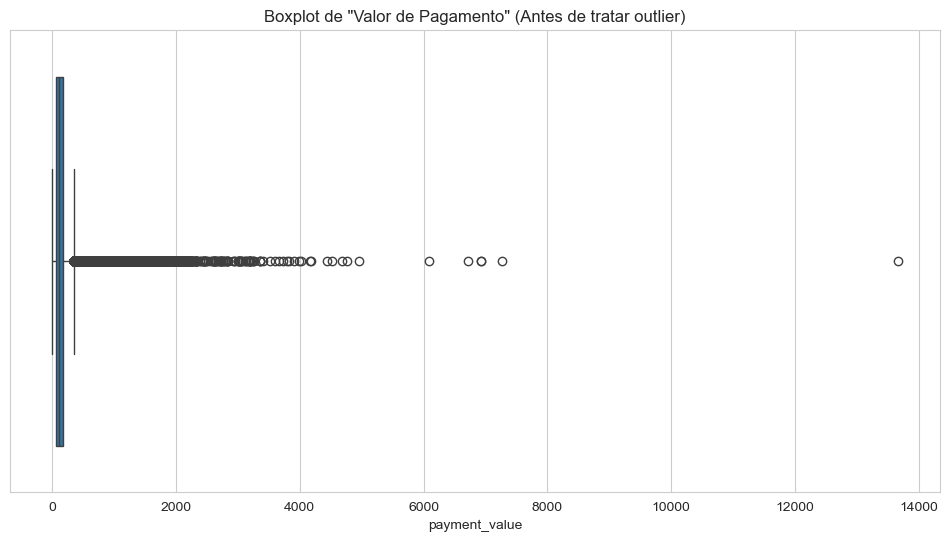

In [18]:
# Visualizando outliers no valores de pagamento
sns.boxplot(x = df_limpo['payment_value'])
plt.title('Boxplot de "Valor de Pagamento" (Antes de tratar outlier)')
plt.show()

In [19]:
# Removendo os valores discrepantes de "payment_value" que estão muito distante da média e dos outros valores.
# Não removeremos todos os outliers pois nossos dados apresentam valores condizentes com as vendas dos valores dos produtos.
# Estes valores podem interferirem em uma análise de inferência estatística.
# Partindo do princípio que temos um produto de valor máximo de 6735.
# Vamos remover outliers acima deste valor para não haver grande influência na análise estatística.
df_limpo = df_limpo[df_limpo['payment_value'] <= 6735]

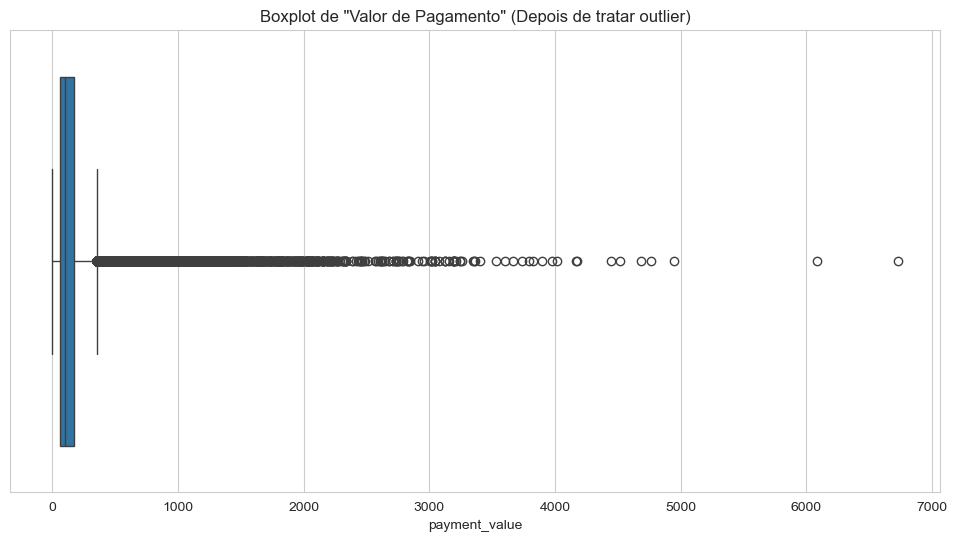

In [20]:
# Visualizando resultado após remoção de outlier na coluna 'payment_value'
sns.boxplot(x = df_limpo['payment_value'])
plt.title('Boxplot de "Valor de Pagamento" (Depois de tratar outlier)')
plt.show()

In [21]:
# Verificação final do DataFrame (tipos de dados e estrutura)
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102357 entries, 0 to 117600
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       102357 non-null  object        
 1   customer_id                    102357 non-null  object        
 2   order_status                   102357 non-null  object        
 3   order_purchase_timestamp       102357 non-null  datetime64[ns]
 4   order_approved_at              102357 non-null  datetime64[ns]
 5   order_delivered_carrier_date   102357 non-null  datetime64[ns]
 6   order_delivered_customer_date  102357 non-null  datetime64[ns]
 7   order_estimated_delivery_date  102357 non-null  datetime64[ns]
 8   customer_unique_id             102357 non-null  object        
 9   customer_city                  102357 non-null  object        
 10  customer_state                 102357 non-null  object        
 11  shipp

In [22]:
# Detecção de valores ausentes
df_limpo.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_city                    0
customer_state                   0
shipping_limit_date              0
price                            0
freight_value                    0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
product_category_name            0
dtype: int64

In [23]:
# Detecção de duplicados
df_limpo.duplicated().sum()

np.int64(0)

In [24]:
# Verificação de estatísticas descritivas após limpezas
df_limpo.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_limit_date,price,freight_value,payment_sequential,payment_installments,payment_value
count,102357,102357,102357,102357,102357,102357,102357.000000,102357.000000,102357.000000,102357.000000,102357.000000
mean,2018-01-01 09:41:43.454556160,2018-01-01 19:53:32.615072768,2018-01-04 14:50:40.772931584,2018-01-13 21:58:21.986693632,2018-01-25 05:11:36.913742848,2018-01-07 23:08:51.067479296,124.207633,20.165579,1.090038,2.891624,156.092429
min,2016-10-03 09:44:50,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-27 00:00:00,2016-10-08 10:34:01,0.850000,0.000000,1.000000,0.000000,0.000000
25%,2017-09-12 20:36:17,2017-09-13 10:07:12,2017-09-15 14:05:17,2017-09-23 12:58:11,2017-10-04 00:00:00,2017-09-19 22:30:27,40.900000,13.180000,1.000000,1.000000,57.680000
50%,2018-01-19 19:15:06,2018-01-20 09:10:39,2018-01-23 22:23:24,2018-02-01 22:39:38,2018-02-15 00:00:00,2018-01-26 13:53:35,78.000000,16.390000,1.000000,1.000000,101.840000
75%,2018-05-05 21:43:43,2018-05-06 14:29:50,2018-05-08 14:53:00,2018-05-16 12:08:33,2018-05-28 00:00:00,2018-05-11 04:14:27,139.000000,21.320000,1.000000,4.000000,175.760000
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,2020-04-09 22:35:08,6499.000000,409.680000,26.000000,24.000000,6726.660000
std,NaN,NaN,NaN,NaN,NaN,NaN,186.275396,15.837600,0.669290,2.721824,209.299169


In [25]:
# Verificação de estatísticas descritivas de colunas categóricas após limpezas
df_limpo.describe(include = [object])

,order_id,customer_id,order_status,customer_unique_id,customer_city,customer_state,payment_type,product_category_name
count,102357,102357,102357,102357,102357,102357,102357,102357
unique,95125,95125,2,92078,4073,27,4,73
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,9a736b248f67d166d2fbb006bcb877c3,sao paulo,SP,credit_card,cama_mesa_banho
freq,42,42,102350,54,16002,43076,75822,10395


#### 6. Engenharia de atributos e extração de insights

In [26]:
# Visualização do DataFrame
df_limpo.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12,utilidades_domesticas
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00,utilidades_domesticas
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59,utilidades_domesticas
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46,perfumaria
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12,automotivo
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,2017-11-23 19:45:59,45.00,27.20,1,credit_card,1,72.20,pet_shop
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,2018-02-19 20:31:37,19.90,8.72,1,credit_card,1,28.62,papelaria
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,congonhinhas,PR,2017-07-13 22:10:13,147.90,27.36,1,credit_card,6,175.26,automotivo
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,nilopolis,RJ,2017-05-22 13:22:11,59.99,15.17,1,credit_card,3,75.16,automotivo
10,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,faxinalzinho,RS,2017-01-27 18:29:09,19.90,16.05,1,boleto,1,35.95,moveis_decoracao


In [27]:
# Receita Total
receita_total = df_limpo['payment_value'].sum()
receita_total

np.float64(15977152.74)

In [28]:
# Receita total por categoria de produto
receita_categoria = df_limpo.groupby('product_category_name')['payment_value'].sum().sort_values(ascending = False)
df_receita_categoria = receita_categoria.to_frame()
df_receita_categoria.reset_index()

,product_category_name,payment_value
0,beleza_saude,1451168.57
1,cama_mesa_banho,1383319.54
2,relogios_presentes,1300579.01
3,esporte_lazer,1158048.82
4,informatica_acessorios,1110716.85
...,...,...
68,pc_gamer,1467.63
69,casa_conforto_2,1332.44
70,cds_dvds_musicais,954.99
71,fashion_roupa_infanto_juvenil,718.98


In [29]:
# Top 5 categoria de produtos por receita
top5_categoria_receita = df_receita_categoria[:5]
top5_categoria_receita

,payment_value
product_category_name,
beleza_saude,1451168.57
cama_mesa_banho,1383319.54
relogios_presentes,1300579.01
esporte_lazer,1158048.82
informatica_acessorios,1110716.85


In [30]:
# As 5 categorias com menor receita
last5_categoria_receita = df_receita_categoria[-5:]
last5_categoria_receita

,payment_value
product_category_name,
pc_gamer,1467.63
casa_conforto_2,1332.44
cds_dvds_musicais,954.99
fashion_roupa_infanto_juvenil,718.98
seguros_e_servicos,324.51


In [31]:
# Análise de vendas ao longo do tempo (por dia)
vendas_por_dia = df_limpo.set_index('order_purchase_timestamp').resample('D')['payment_value'].sum()
vendas_por_dia

order_purchase_timestamp
2016-10-03      595.14
2016-10-04    10248.00
2016-10-05     7696.67
2016-10-06     6984.21
2016-10-07     7096.69
                ...   
2018-08-25    12403.91
2018-08-26     9606.41
2018-08-27     6255.13
2018-08-28     4260.66
2018-08-29     1762.70
Freq: D, Name: payment_value, Length: 696, dtype: float64

In [32]:
# Análise de vendas ao longo do tempo (por mês)
vendas_por_mes = df_limpo.set_index('order_purchase_timestamp').resample('M')['payment_value'].sum()
vendas_por_mes

C:\Users\marqu\AppData\Local\Temp\ipykernel_10296\824219386.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vendas_por_mes = df_limpo.set_index('order_purchase_timestamp').resample('M')['payment_value'].sum()


order_purchase_timestamp
2016-10-31      49571.80
2016-11-30          0.00
2016-12-31         19.62
2017-01-31     131922.68
2017-02-28     264322.50
2017-03-31     422608.91
2017-04-30     393476.24
2017-05-31     582968.75
2017-06-30     507393.67
2017-07-31     597880.46
2017-08-31     673764.56
2017-09-30     707583.40
2017-10-31     777398.36
2017-11-30    1203543.01
2017-12-31     861397.55
2018-01-31    1119481.82
2018-02-28     984956.17
2018-03-31    1147564.78
2018-04-30    1186628.64
2018-05-31    1194722.09
2018-06-30    1059764.55
2018-07-31    1056510.61
2018-08-31    1053672.57
Freq: ME, Name: payment_value, dtype: float64

In [33]:
# Observando o pior e o melhor mês de vendas
vendas_por_mes.sort_values()

order_purchase_timestamp
2016-11-30          0.00
2016-12-31         19.62
2016-10-31      49571.80
2017-01-31     131922.68
2017-02-28     264322.50
2017-04-30     393476.24
2017-03-31     422608.91
2017-06-30     507393.67
2017-05-31     582968.75
2017-07-31     597880.46
2017-08-31     673764.56
2017-09-30     707583.40
2017-10-31     777398.36
2017-12-31     861397.55
2018-02-28     984956.17
2018-08-31    1053672.57
2018-07-31    1056510.61
2018-06-30    1059764.55
2018-01-31    1119481.82
2018-03-31    1147564.78
2018-04-30    1186628.64
2018-05-31    1194722.09
2017-11-30    1203543.01
Name: payment_value, dtype: float64

In [34]:
# Análise de vendas ao longo do tempo (por ano)
vendas_por_ano = df_limpo.set_index('order_purchase_timestamp').resample('Y')['payment_value'].sum()
vendas_por_ano.index = vendas_por_ano.index.to_period('Y')
vendas_por_ano

C:\Users\marqu\AppData\Local\Temp\ipykernel_10296\3054418896.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  vendas_por_ano = df_limpo.set_index('order_purchase_timestamp').resample('Y')['payment_value'].sum()


order_purchase_timestamp
2016      49591.42
2017    7124260.09
2018    8803301.23
Freq: Y-DEC, Name: payment_value, dtype: float64

In [35]:
# Receita por estado (UF)
receita_estado = df_limpo.groupby('customer_state')['payment_value'].sum().sort_values(ascending = False)
df_receita_estado = receita_estado.to_frame()
df_receita_estado.reset_index()

,customer_state,payment_value
0,SP,6024120.20
1,RJ,2114981.89
2,MG,1882218.15
3,RS,893564.99
4,PR,804992.92
5,SC,613269.57
6,BA,612708.03
7,DF,363967.11
8,GO,344952.32
9,ES,316061.03


In [36]:
# Top 10 estados por receita
top10_receita_estado = df_receita_estado[:10]
top10_receita_estado

,payment_value
customer_state,
SP,6024120.20
RJ,2114981.89
MG,1882218.15
RS,893564.99
PR,804992.92
SC,613269.57
BA,612708.03
DF,363967.11
GO,344952.32


In [37]:
# Receita por cidade
receita_cidade = df_limpo.groupby('customer_city')['payment_value'].sum().sort_values(ascending = False)
df_receita_cidade = receita_cidade.to_frame()
df_receita_cidade.reset_index()

,customer_city,payment_value
0,sao paulo,2205247.33
1,rio de janeiro,1133278.74
2,belo horizonte,416261.43
3,brasilia,363076.90
4,curitiba,244106.49
...,...,...
4068,santo antonio do rio abaixo,24.23
4069,tamboara,24.09
4070,jenipapo de minas,22.58
4071,polo petroquimico de triunfo,20.70


In [38]:
# Top 10 cidades por receita
top10_receita_cidade = df_receita_cidade[:10]
top10_receita_cidade

,payment_value
customer_city,
sao paulo,2205247.33
rio de janeiro,1133278.74
belo horizonte,416261.43
brasilia,363076.90
curitiba,244106.49
porto alegre,223951.86
campinas,218901.80
salvador,213563.45
guarulhos,162545.48


In [39]:
# Verificando frequência absoluta do status dos pedidos (entregues e cancelados)
status_pedido = df_limpo['order_status'].value_counts()
status_pedido

order_status
delivered    102350
canceled          7
Name: count, dtype: int64

In [40]:
# Verificando frequência absoluta dos métodos de pagamento utilizados na plataforma
metodo_pagamento = df_limpo['payment_type'].value_counts()
metodo_pagamento

payment_type
credit_card    75822
boleto         19433
voucher         5595
debit_card      1507
Name: count, dtype: int64

In [41]:
# Criando condições de entrega dos pedidos (se 'no prazo' ou 'atrasado')
condicoes = [
    df_limpo['order_delivered_customer_date'] > df_limpo['order_estimated_delivery_date'],
    df_limpo['order_delivered_customer_date'] <= df_limpo['order_estimated_delivery_date']
]
rotulos = ['Atrasado', 'No prazo']

In [42]:
# Criação de coluna da condição de entrega
df_limpo['Condição de entrega'] = np.select(condicoes, rotulos, default = 'prazo não informado')

In [43]:
# Verificando DataFrame com nova coluna criada
df_limpo.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,Condição de entrega
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12,utilidades_domesticas,No prazo
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00,utilidades_domesticas,No prazo
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59,utilidades_domesticas,No prazo
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46,perfumaria,No prazo
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12,automotivo,No prazo


In [44]:
# Verifcando frequência absoluta da condição de entrega
pontualidade = df_limpo['Condição de entrega'].value_counts()
pontualidade

Condição de entrega
No prazo    94244
Atrasado     8113
Name: count, dtype: int64

#### 7. Análises e visualização de dados

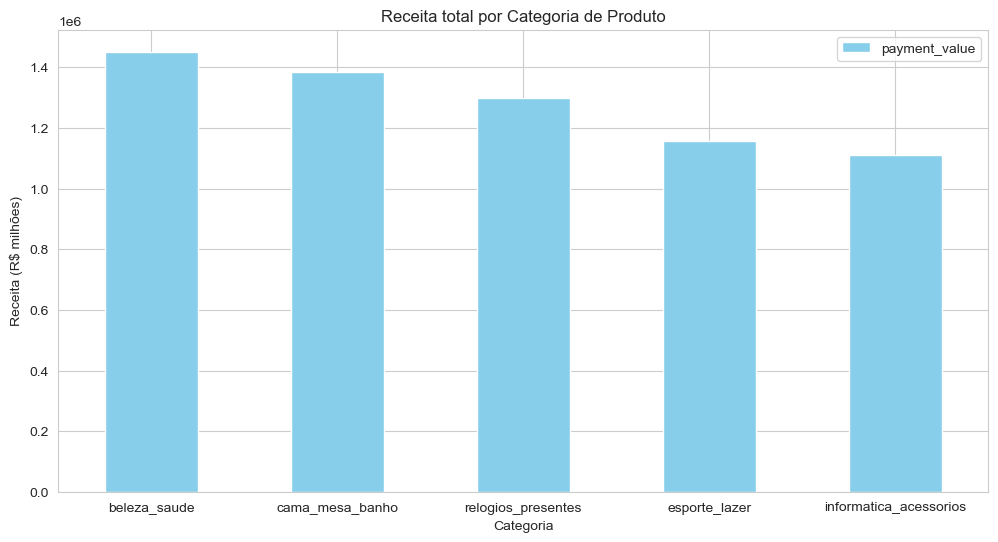

In [45]:
# Top 5 receitas por categria de produto
top5_categoria_receita.plot(kind = 'bar', color = 'skyblue')
plt.title('Receita total por Categoria de Produto')
plt.ylabel('Receita (R$ milhões)')
plt.xlabel('Categoria')
plt.xticks(rotation = 0)
plt.show()

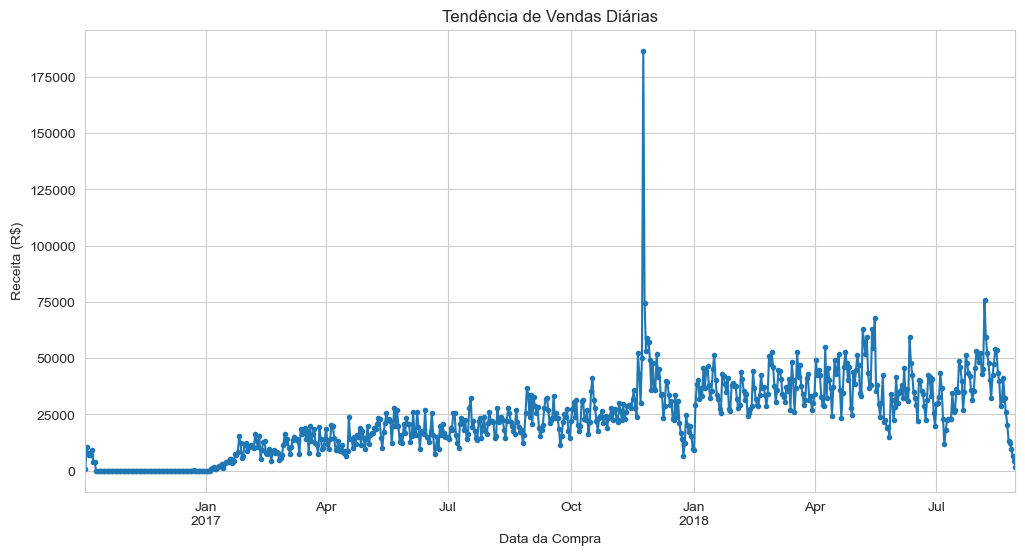

In [46]:
# Tendência de vendas ao longo do tempo (por dia)
vendas_por_dia.plot(kind = 'line', marker = '.', linestyle = '-')
plt.title('Tendência de Vendas Diárias')
plt.ylabel('Receita (R$)')
plt.xlabel('Data da Compra')
plt.grid(True)
plt.show()

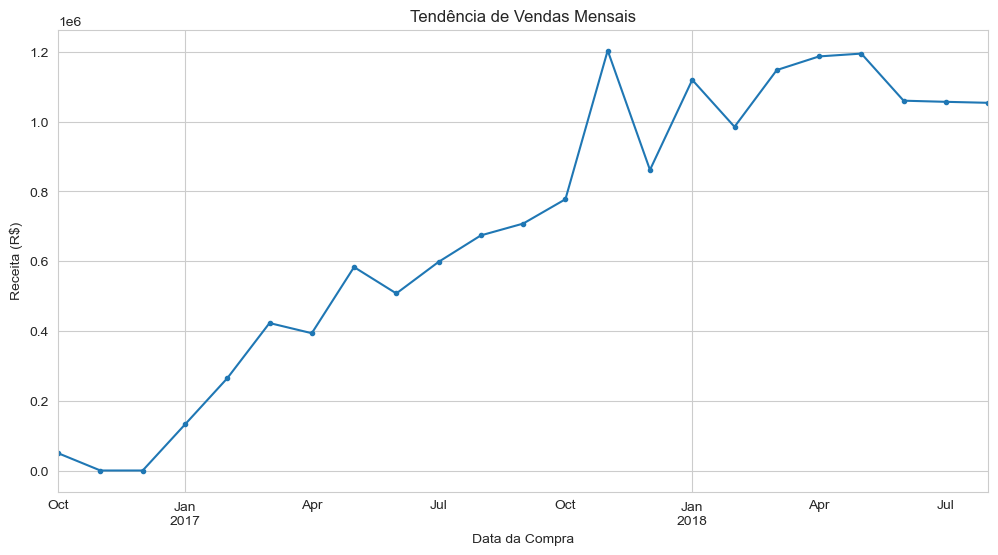

In [47]:
# Tendência de vendas ao longo do tempo (por mês)
vendas_por_mes.plot(kind = 'line', marker = '.', linestyle = '-')
plt.title('Tendência de Vendas Mensais')
plt.ylabel('Receita (R$)')
plt.xlabel('Data da Compra')
plt.grid(True)
plt.show()

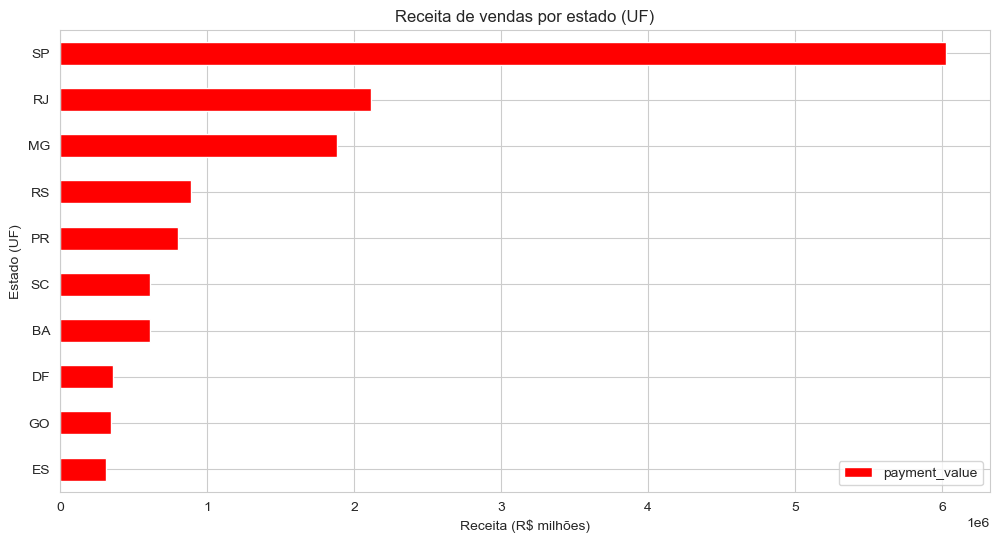

In [48]:
# Top 10 estados com maior receita de vendas
top10_receita_estado.plot(kind = 'barh', color = 'red')
plt.title('Receita de vendas por estado (UF)')
plt.ylabel('Estado (UF)')
plt.xlabel('Receita (R$ milhões)')
plt.gca().invert_yaxis() # Inverte o eixo para o maior valor ficar no topo
plt.show()

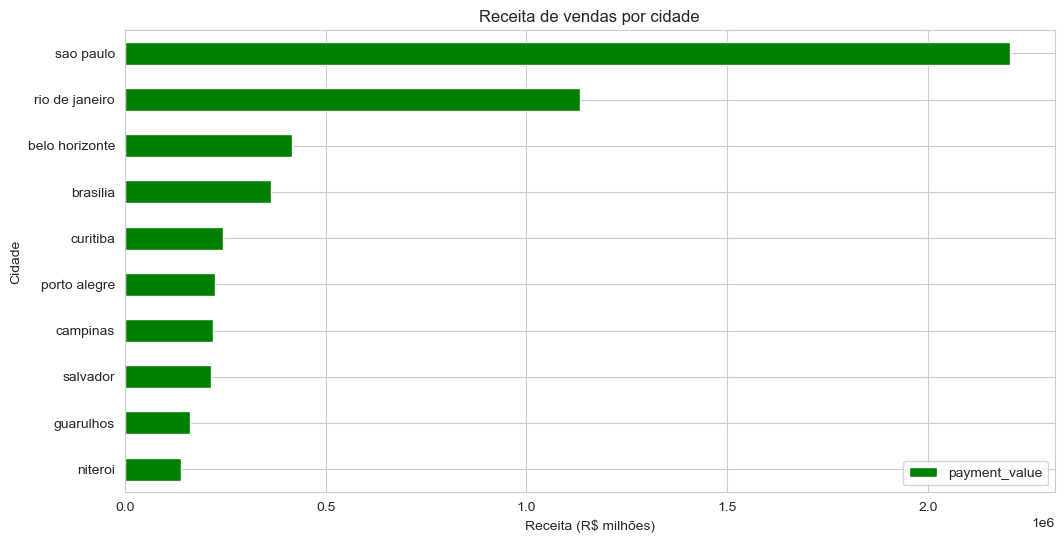

In [49]:
# Top 10 cidades com maior receita de vendas
top10_receita_cidade.plot(kind = 'barh', color = 'green')
plt.title('Receita de vendas por cidade')
plt.ylabel('Cidade')
plt.xlabel('Receita (R$ milhões)')
plt.gca().invert_yaxis() # Inverte o eixo para o maior valor ficar no topo
plt.show()

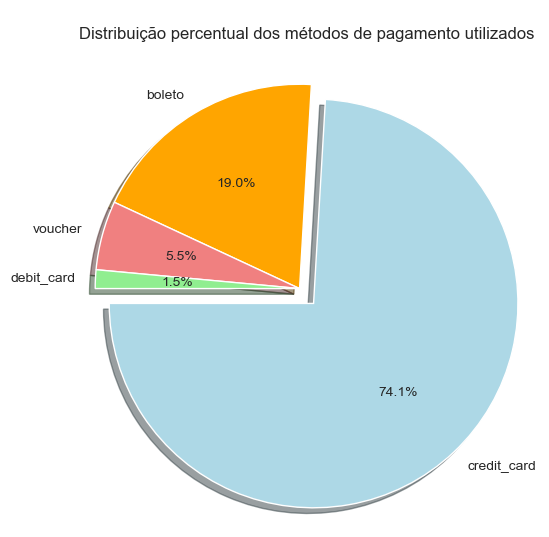

In [50]:
# Distribuição percentual de utilização de cada método de pagamento
maior_idx = metodo_pagamento.argmax()
explode = [0.1 if i == maior_idx else 0 for i in range(len(metodo_pagamento))]
plt.figure(figsize = (6,6))
plt.pie(
    metodo_pagamento,                
    labels = metodo_pagamento.index,  
    autopct = '%1.1f%%',            
    startangle = 180,              
    colors = ['lightblue',        
              'orange',            
              'lightcoral',
             'lightgreen'],       
    explode = explode,             
    shadow = True                  
)
plt.title('\nDistribuição percentual dos métodos de pagamento utilizados\n')  
plt.axis('equal')                                   
plt.show()

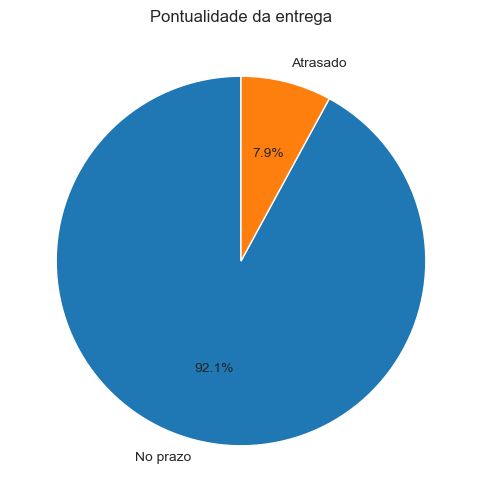

In [51]:
# Status do prazo de entrega (pontualidade de entrega)
pontualidade.plot(kind = 'pie', autopct = '%1.1f%%', figsize = (6, 6), startangle = 90)
plt.title('Pontualidade da entrega')
plt.ylabel('')
plt.show()

#### 8. Conclusões, insights e recomendações

##### 8.1. Receita Total e Receita por Categoria de Produto

A receita total de vendas dentro do periodo analisado foi de R$15.977.152,74

As 5 categorias de produtos **(Top 5 categorias de produtos)** com maiores receitas no período, foram:

1 - Beleza e saúde: R$1.451.168,57

2 - Cama, mesa e banho: R$1.383.319,54

3 - Relógios e presentes: R$1.300.579,01

4 - Esportes e lazer: R$1.158.048,82

5 - Informática e acessórios: R$1.110.716,85

Já as 5 categorias que tiveram menores receitas no período, foram:

1 - PC Gamer: R$1.467,63

2 - Casa e conforto 2: R$1.332,44

3 - CD’s e DVD’s musicais: R$954,99

4 - Fashion, roupa infanto-juvenil: R$718,98

5 - Seguros e serviços: R$324,51

##### 8.2. Crescimento de receita no período

Quando analisamos o crescimento das vendas no período, observamos um crescimento nas vendas diárias e mensais, e um tendência de crescimento nas vendas anuais.
O melhor mês de vendas foi novembro de 2017 com uma receita de R$1.203.543,01.
E o pior mês de vendas foi novembro de 2016 com zero vendas.

##### 8.3 Receitas por estado

Os 10 estados **(Top 10 estados - UF)** com maiores receitas são:

1 -	SP	6024120.20

2 -	RJ	2114981.89

3 -	MG	1882218.15

4 -	RS	893564.99

5 -	PR	804992.92

6 -	SC	613269.57

7 -	BA	612708.03

8 -	DF	363967.11

9 -	GO	344952.32

10 - ES	316061.03

As 10 cidades **(Top 10 cidades)** com maiores receitas são:

1 - sao paulo	2205247.33

2 - rio de janeiro	1133278.74

3 - belo horizonte	416261.43

4 - brasilia	363076.90

5 - curitiba	244106.49

6 - porto alegre	223951.86

7 - campinas	218901.80

8 - salvador	213563.45

9 - guarulhos	162545.48

10 - niteroi	140762.75

##### 8.4. Métodos de pagamento

O método de pagamento mais utilizado na plataforma é o cartão de crédito, concentrando 74% dos pagamentos realizados. Em segundo lugar o boleto com 19%, voucher e cartão de débito vêm em seguida com 5,5% e 1,5% respectivamente.

##### 8.5. Atraso nos pedidos

Dentro do período analisado 102.357 pedidos foram realizados na plataforma, destes 94.244 (92,1%) foram entregues no prazo e 8.113 (7,9%) foram entregues com atraso.

##### 8.6 Recomendações

A empresa apresenta um nível de receitas saudável no período  analisado. Como destaque elenco o nível de participação nas receitas dos estados de SP, RJ e MG que concentraram sozinhos 63% das receitas da empresa dentro do período, o que demanda especial atenção da empresa destinada a estes estados dada sua relevância nas vendas da plataforma.

As top 5 categorias de produtos destacadas como de maiores receitas concentraram 40% de participação na receita total da empresa. E as 5 categorias de produtos de menores receitas concentraram menos de 0,05% de participação na receita dentro do período analisado, a empresa deve questionar-se se vale o investimento e a sustentação da base de custos para manter estes produtos a venda.

Quanto ao atraso nos pedidos que se aproximaram de 8% da base analisada, a empresa deve manter especial atenção ao fator logístico evitando avaliações negativas no mercado e desgate de sua imagem.

Faço as seguintes sugestões de estudos futuros: Análise de custos de venda das categorias de produtos e análise dos centros logísticos de distribuição da empresa.